In [36]:
import pandas as pd
import numpy as np
import sys
import os
import time
import random
import copy
import math
import scanpy as sc
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import autoreload
import scipy
params = {
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 8,
    'ytick.labelsize': 10,
    'font.family': "Helvetica",
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 100
   }

mpl.rcParams.update(params)

sns.set_style("ticks")
sns.set_context(context='paper')
savefig_args = {"dpi": 300, "bbox_inches": "tight", "pad_inches": 0, "transparent": False}
mpl.rc('savefig', dpi=300)
output_dir='figures/10.12.20/'
output_suffix = ""
output_formats = [".png", ".pdf"]

def save_figure(fig, name, output_dir=output_dir, output_suffix=output_suffix, output_formats=output_formats, savefig_args=savefig_args):
    for output_format in output_formats:
        fig.savefig(output_dir + "/" + name + output_suffix + output_format, **savefig_args)
    return None

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20) 
pd.set_option('display.width', 100)
%load_ext autoreload
%autoreload 2
cfgFile = '../switchy/Prototyping.ini'

sc.set_figure_params(color_map='viridis')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


IL_genes = list(adata.var.index[adata.var.index.str.contains("IL")])

sc.pl.umap(adata, color = IL_genes)

## Analysis

In [2]:
filename = 'Current.h5ad'
adata = sc.read_h5ad(filename)

/Users/mswift/miniconda3/envs/seqclone/lib/python3.8/site-packages/anndata/compat/__init__.py:158: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/Users/mswift/miniconda3/envs/seqclone/lib/python3.8/site-packages/anndata/compat/__init__.py:158: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


Text(0.5, 1.0, 'Uniquely Mapped Reads')

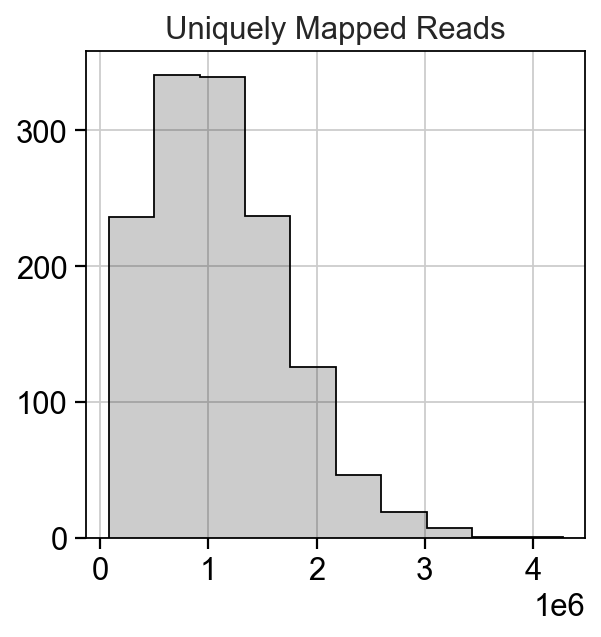

In [19]:
fig, ax = plt.subplots(1,1)
plt.hist(adata.obs.n_counts, histtype='step', color = 'k')
plt.hist(adata.obs.n_counts, histtype='stepfilled', color = 'k', alpha = 0.2)
plt.title('Uniquely Mapped Reads')

In [23]:
adata.obs

,Donor,Experimental_Label,Treatment,Division_Number,CLONE,ISOTYPE,SEQUENCE_ID,Assembly,n_genes_by_counts,log1p_n_genes_by_counts,...,n_genes,S_score,G2M_score,phase,leiden,groups,B cell States,group,exon_simple,Switched
cell,,,,,,,,,,,,,,,,,,,,,
CTY_I8,Donor_1,Activation_1,Activation,4,1160.0,IGHM,bracer_CTY_I8_TRINITY_DN0_c0_g1_i1_H Donor_1,AAGGTGTCCAGTGTGAAGTGCAGCTGGTGGAGTCTGGGGGAGGCTT...,7439,8.914626,...,7276,0.209589,0.310509,G2M,Helper B (2),Other States,Helper B,Other States,IGHM,Not Switched
MS_SISTER2_J10,Donor_1,Activation_2,Activation,3,427.0,IGHD,bracer_MS_SISTER2_J10_TRINITY_DN2_c0_g3_i1_H D...,ATGGGTCCTGTCCCAGGTGCAGCTGCAGGAGTCGGGCCCAGGACTG...,9518,9.161045,...,9244,0.152560,0.178335,G2M,Helper B (1),Other States,Helper B,Other States,IGHM,Not Switched
NaiveBcellsplate2_20180629_D23,Donor_1,Naive_1,Naive,None,248.0,IGHM,bracer_NaiveBcellsplate2_20180629_D23_TRINITY_...,GTCGTCAGATCTCAGGCTCCTCACCATGGACTGGACCTGGAGCATC...,2119,7.659171,...,1926,-0.113852,-0.157119,G1,Unstimulated,Other States,Unstimulated,Other States,IGHM,Not Switched
NaiveBcellsplate2_20180629_K4,Donor_1,Naive_1,Naive,None,40.0,nan,nan,nan,1267,7.145196,...,1046,-0.128058,-0.164089,G1,Unstimulated,Other States,Unstimulated,Other States,IGHM,Not Switched
NaiveBcellsplate2_20180629_P1,Donor_1,Naive_1,Naive,None,565.0,IGHD,bracer_NaiveBcellsplate2_20180629_P1_TRINITY_D...,GTACATGGGGCTTTCTGAGAGTCATGGATCTCATGTGCAAGAAAAT...,2329,7.753624,...,1883,-0.170908,-0.199337,G1,Unstimulated,Other States,Unstimulated,Other States,IGHM,Not Switched
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P1_5_23_19_D2_H8,Donor_2,Activation_4,Activation,Max,1687.0,nan,nan,nan,3845,8.254789,...,3794,-0.233964,-0.211757,G1,Switching,Switching,Switching,Other States,IGHG1,Switched
P1_5_23_19_D2_A19,Donor_2,Activation_4,Activation,Max,1149.0,IGHM,bracer_P1_5_23_19_D2_A19_TRINITY_DN4_c0_g1_i4_...,TCTGAGGATCTCCTGTAAGGGTTCTGGATACAGCTTTACCAGCTAC...,4573,8.428143,...,4460,0.155491,0.016282,S,Switching,Switching,Switching,Other States,IGHM,Not Switched
P1_5_23_19_D2_M5,Donor_2,Activation_4,Activation,Max,1618.0,IGHG2,bracer_P1_5_23_19_D2_M5_TRINITY_DN3_c1_g1_i1_H...,TGGTGGCAGCAGCTACAGGTGTCCAGTCCCAGGTGCAGCTGGTGCA...,3340,8.114025,...,3257,-0.222022,-0.335339,G1,Switching,Switching,Switching,Other States,IGHG1,Switched


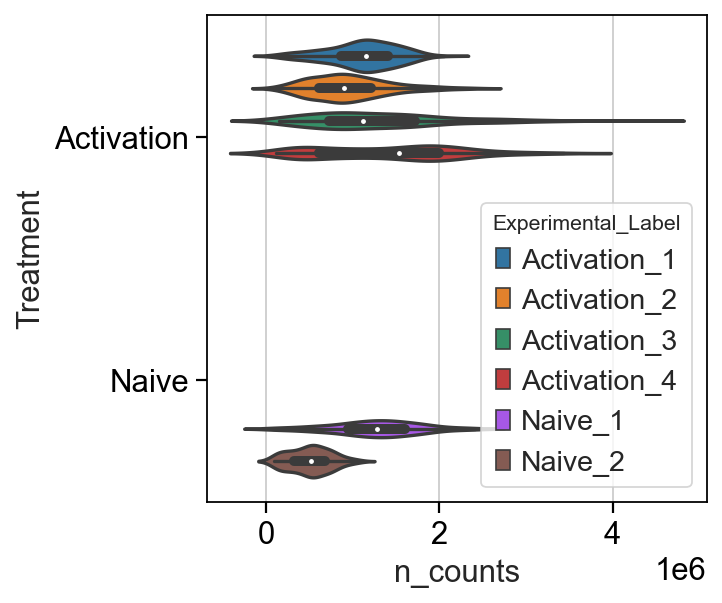

In [28]:
g = sns.violinplot(data = adata.obs, x ='n_counts', y = 'Treatment', hue = 'Experimental_Label')

In [30]:
g.figure.savefig('figures/N_counts', transparent=True)

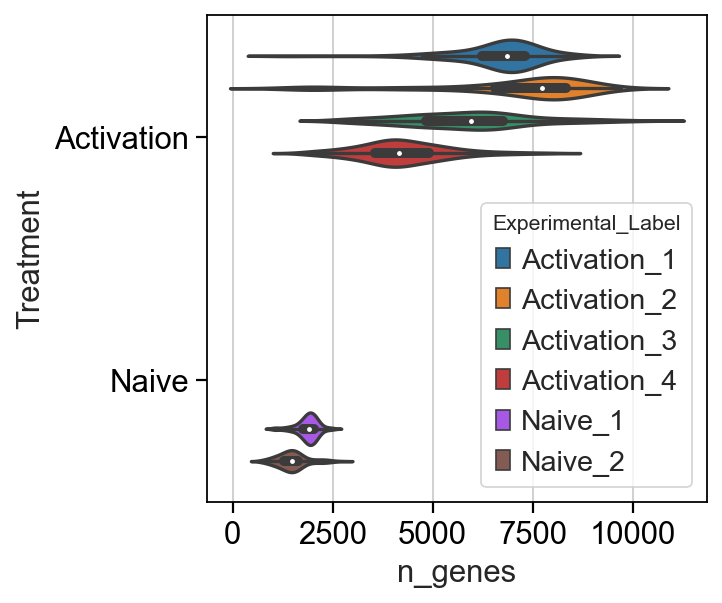

In [31]:
g = sns.violinplot(data = adata.obs, x ='n_genes', y = 'Treatment', hue = 'Experimental_Label')

In [38]:
adata.obs.columns

Index(['Donor', 'Experimental_Label', 'Treatment', 'Division_Number', 'CLONE', 'ISOTYPE',
       'SEQUENCE_ID', 'Assembly', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'n_genes',
       'S_score', 'G2M_score', 'phase', 'leiden', 'groups', 'B cell States', 'group',
       'exon_simple', 'Switched'],
      dtype='object')

In [32]:
g.figure.savefig('figures/N_genes', transparent=True)

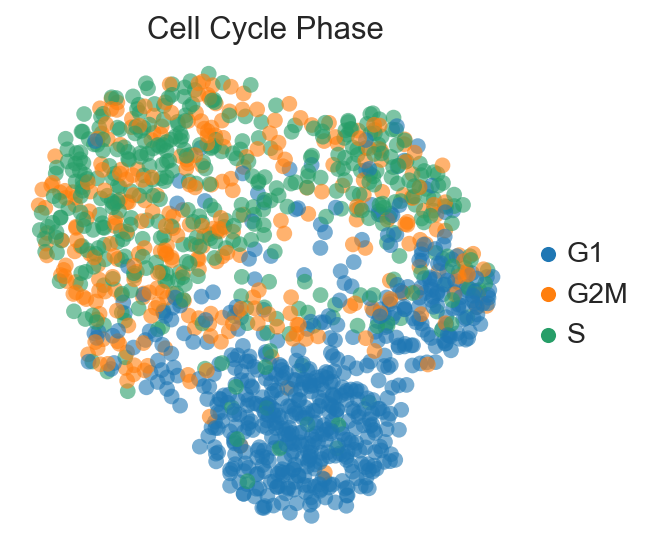

In [35]:
variable = 'phase'
sc.pl.umap(adata, color = variable, title = 'Cell Cycle Phase', frameon = False, size = 200, alpha=0.6, save = variable)